In [1]:
import pandas as pd 
import seaborn as sns

In [2]:
df = pd.read_csv('dds_datasets/dds_ch2_nyt/nyt1.csv')
df

,Age,Gender,Impressions,Clicks,Signed_In
0,36,0,3,0,1
1,73,1,3,0,1
2,30,0,3,0,1
3,49,1,3,0,1
4,47,1,11,0,1
...,...,...,...,...,...
458436,0,0,2,0,0
458437,0,0,4,0,0
458438,72,1,5,0,1
458439,0,0,5,0,0


In [3]:
df.columns =(df.columns.str.lower().str.replace('-' , '_'))
df.columns

Index(['age', 'gender', 'impressions', 'clicks', 'signed_in'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458441 entries, 0 to 458440
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   age          458441 non-null  int64
 1   gender       458441 non-null  int64
 2   impressions  458441 non-null  int64
 3   clicks       458441 non-null  int64
 4   signed_in    458441 non-null  int64
dtypes: int64(5)
memory usage: 17.5 MB


In [5]:
df.duplicated().sum()

np.int64(453503)

In [6]:
df.describe()

,age,gender,impressions,clicks,signed_in
count,458441.000000,458441.000000,458441.000000,458441.000000,458441.000000
mean,29.482551,0.367037,5.007316,0.092594,0.700930
std,23.607034,0.481997,2.239349,0.309973,0.457851
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3.000000,0.000000,0.000000
50%,31.000000,0.000000,5.000000,0.000000,1.000000
75%,48.000000,1.000000,6.000000,0.000000,1.000000
max,108.000000,1.000000,20.000000,4.000000,1.000000


In [7]:
bins = [0,10 ,20 ,30 ,40 ,50 ,60,110]
labels = ['>9' , '10-19' , '20-29' , '30-39' , '40-49' , '50-59' , '60+']
df['age-qroup'] = pd.cut(df.age , bins , labels=labels , include_lowest=True)
df

,age,gender,impressions,clicks,signed_in,age-qroup
0,36,0,3,0,1,30-39
1,73,1,3,0,1,60+
2,30,0,3,0,1,20-29
3,49,1,3,0,1,40-49
4,47,1,11,0,1,40-49
...,...,...,...,...,...,...
458436,0,0,2,0,0,>9
458437,0,0,4,0,0,>9
458438,72,1,5,0,1,60+
458439,0,0,5,0,0,>9


<Axes: xlabel='age-qroup', ylabel='count'>

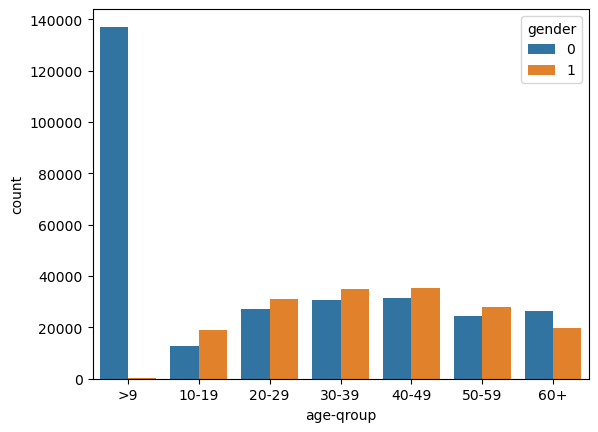

In [8]:
sns.countplot(x = 'age-qroup' , hue= 'gender' , data =df)

<Axes: xlabel='clicks', ylabel='count'>

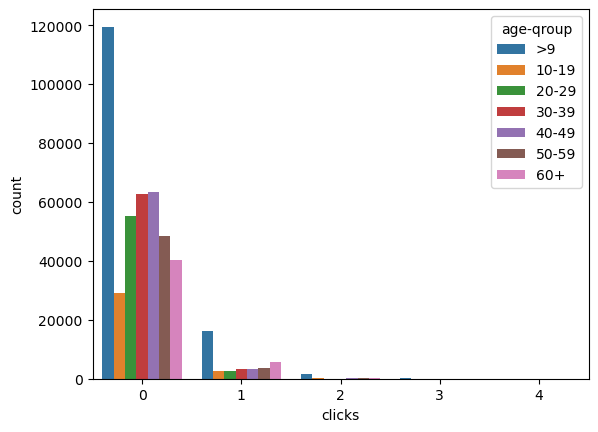

In [9]:
sns.countplot(x = 'clicks' , hue= 'age-qroup' , data =df)

In [10]:
df[(df.clicks >0) & (df.impressions == 0)]

,age,gender,impressions,clicks,signed_in,age-qroup


<Axes: xlabel='impressions', ylabel='Count'>

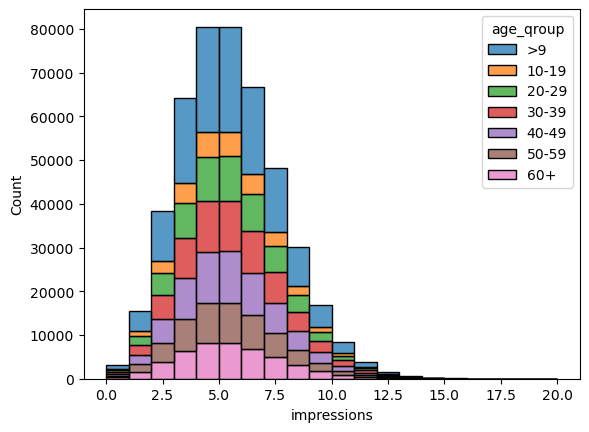

In [19]:
sns.histplot(x = 'impressions' , hue= 'age_qroup' , data =df , binwidth =1 , multiple='stack')

In [12]:
df.columns =(df.columns.str.lower().str.replace('-' , '_'))
df.columns

Index(['age', 'gender', 'impressions', 'clicks', 'signed_in', 'age_qroup'], dtype='object')

<Axes: xlabel='age_qroup', ylabel='impressions'>

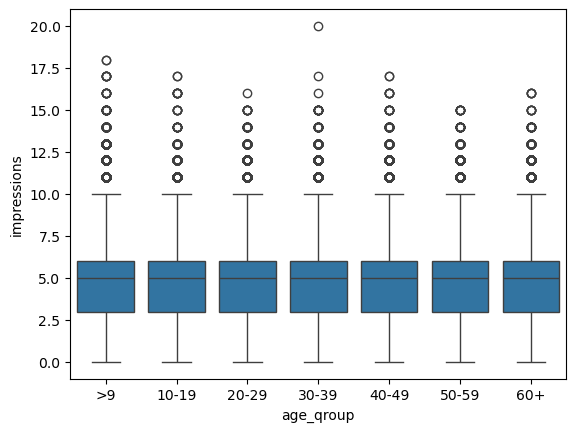

In [13]:
sns.boxplot(y= df.impressions , x=df.age_qroup)

In [27]:
df['CTR'] = round(df.clicks / df.impressions , 1)
df.head()

,age,gender,impressions,clicks,signed_in,age_qroup,CTR
0,36,0,3,0,1,30-39,0.0
1,73,1,3,0,1,60+,0.0
2,30,0,3,0,1,20-29,0.0
3,49,1,3,0,1,40-49,0.0
4,47,1,11,0,1,40-49,0.0


In [30]:
s =df[df.clicks == 1]
s.head()

,age,gender,impressions,clicks,signed_in,age_qroup,CTR
5,47,0,11,1,1,40-49,0.1
6,0,0,7,1,0,>9,0.1
10,0,0,8,1,0,>9,0.1
63,0,0,2,1,0,>9,0.5
72,0,0,6,1,0,>9,0.2


<Axes: xlabel='age_qroup', ylabel='CTR'>

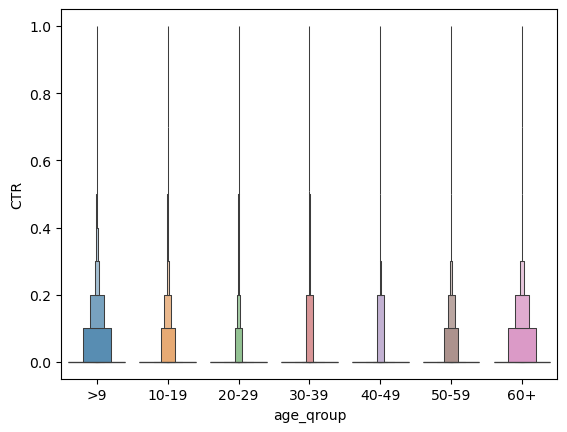

In [35]:
sns.boxenplot(x = df.age_qroup ,y=df.CTR ,hue=df.age_qroup )

In [43]:
bins = [-1,0 ,0.1 ,0.2 ,0.4 , 1]
labels = ['0%' , '<10%' , '10%-20%' , '20%-40%' , '>40%']
df['CTR_qroup'] = pd.cut(df.CTR , bins , labels=labels )
df.CTR_qroup.value_counts(normalize = True , sort=True)

CTR_qroup
0%         0.912516
10%-20%    0.042602
<10%       0.030182
20%-40%    0.010251
>40%       0.004449
Name: proportion, dtype: float64

In [48]:
df_C_A = df[df.CTR >0]
df_C_A

,age,gender,impressions,clicks,signed_in,age_qroup,CTR,CTR_qroup
5,47,0,11,1,1,40-49,0.1,<10%
6,0,0,7,1,0,>9,0.1,<10%
10,0,0,8,1,0,>9,0.1,<10%
39,0,0,7,2,0,>9,0.3,20%-40%
63,0,0,2,1,0,>9,0.5,>40%
...,...,...,...,...,...,...,...,...
458390,19,0,5,1,1,10-19,0.2,10%-20%
458392,47,0,5,1,1,40-49,0.2,10%-20%
458402,0,0,5,1,0,>9,0.2,10%-20%
458407,0,0,4,1,0,>9,0.2,10%-20%


In [49]:
df_C_A.age_qroup.value_counts(normalize = True , sort=True)

age_qroup
>9       0.446985
60+      0.146644
50-59    0.095211
40-49    0.083990
30-39    0.082886
10-19    0.073498
20-29    0.070787
Name: proportion, dtype: float64

<Axes: xlabel='age_qroup', ylabel='CTR'>

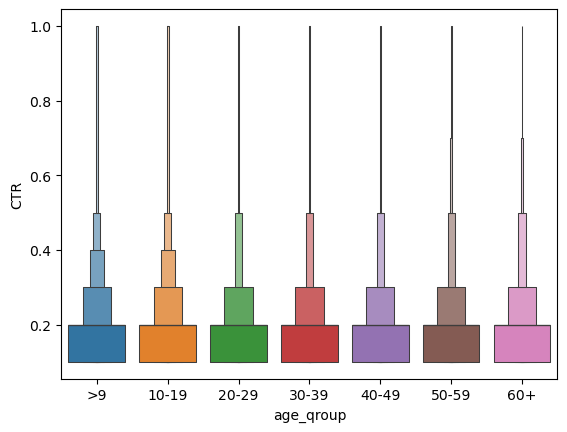

In [50]:
sns.boxenplot(x = df_C_A.age_qroup ,y=df_C_A.CTR ,hue=df_C_A.age_qroup )

<Axes: xlabel='age_qroup', ylabel='count'>

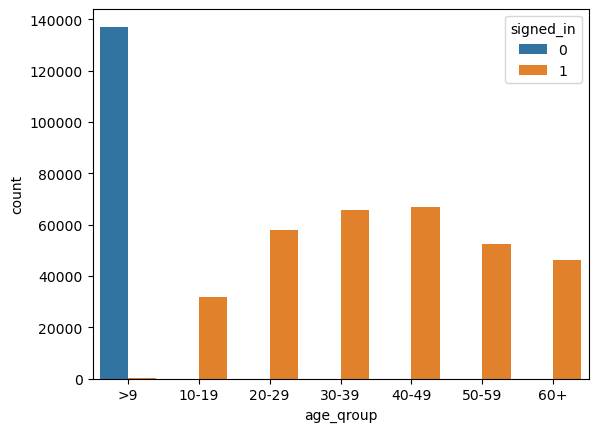

In [54]:
sns.countplot(x = df.age_qroup,hue=df.signed_in )